#  Tầng 3a: Preliminary Analysis — Single-Choice Questions

**Mục tiêu:** Vẽ Pie / Bar chart (tính theo %) cho các biến nhân khẩu học  
và các câu hỏi lựa chọn đơn.

**Input:** `processed/cleaned_responses.csv`  
**Output:** Biểu đồ lưu vào thư mục `reports/figures/1_demographics_descriptive/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import os
from pathlib import Path

from pathlib import Path
# Ensure paths resolve from the project root when notebooks run from notebooks/.
import os
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
# ══════════════════════════════════════════════════════════
# SETUP
# ══════════════════════════════════════════════════════════

# Tạo thư mục reports/figures nếu chưa có
os.makedirs("reports/figures/1_demographics_descriptive", exist_ok=True)

# Font hỗ trợ tiếng Việt (Windows)
matplotlib.rcParams["font.family"] = "Arial"
matplotlib.rcParams["axes.unicode_minus"] = False

# Seaborn theme
sns.set_theme(style="whitegrid", palette="muted", font="Arial")

# Color palettes
PIE_COLORS = sns.color_palette("Set2", 10)
BAR_PALETTE = "viridis"

# Đọc dữ liệu
INPUT_FILE = "processed/cleaned_responses.csv"
assert Path(INPUT_FILE).exists(), f"[ERROR] Chưa có {INPUT_FILE}!"
df = pd.read_csv(INPUT_FILE, encoding="utf-8-sig")
N = len(df)
print(f"[OK] Đọc {INPUT_FILE}: {N} responses × {df.shape[1]} cột")

[OK] Đọc processed/cleaned_responses.csv: 129 responses × 41 cột


In [2]:
# ══════════════════════════════════════════════════════════
# HÀM TIỆN ÍCH - Tái sử dụng cho mọi biểu đồ
# ══════════════════════════════════════════════════════════

def plot_pie(series, title, filename, figsize=(8, 6), min_pct=3.0):
    """
    Vẽ Pie chart với label hiển thị % + count.
    Nhóm các lát nhỏ hơn min_pct% thành 'Khác'.
    """
    counts = series.value_counts()
    pcts = counts / counts.sum() * 100

    # Nhóm lát nhỏ thành "Khác"
    small_mask = pcts < min_pct
    if small_mask.any():
        other_count = counts[small_mask].sum()
        counts = pd.concat([counts[~small_mask], pd.Series({"Khác": other_count})])

    fig, ax = plt.subplots(figsize=figsize)
    wedges, texts, autotexts = ax.pie(
        counts.values,
        labels=None,
        autopct=lambda p: f"{p:.1f}%\n({int(round(p * counts.sum() / 100))})",
        colors=PIE_COLORS[:len(counts)],
        startangle=140,
        pctdistance=0.75,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    )

    for t in autotexts:
        t.set_fontsize(9)
        t.set_fontweight("bold")

    # Legend bên ngoài
    labels_legend = [f"{name}" for name in counts.index]
    ax.legend(wedges, labels_legend, title="Nhóm", loc="center left",
              bbox_to_anchor=(1.0, 0.5), fontsize=9, title_fontsize=10)

    ax.set_title(title, fontsize=13, fontweight="bold", pad=15)
    plt.tight_layout()
    plt.savefig(f"reports/figures/1_demographics_descriptive/{filename}", bbox_inches="tight", dpi=150)
    plt.show()
    print(f"   Saved: Saved: reports/figures/1_demographics_descriptive/{filename}")


def plot_bar_horizontal(series, title, filename, figsize=(10, 5), palette=BAR_PALETTE):
    """
    Vẽ Bar chart ngang với % annotation.
    """
    counts = series.value_counts()
    pcts = (counts / counts.sum() * 100).round(1)

    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.barh(
        range(len(counts)),
        counts.values,
        color=sns.color_palette(palette, len(counts)),
        edgecolor="white",
        linewidth=0.8,
    )

    ax.set_yticks(range(len(counts)))
    ax.set_yticklabels(counts.index, fontsize=9)
    ax.invert_yaxis()

    # Annotation: count + %
    for i, (val, pct) in enumerate(zip(counts.values, pcts.values)):
        ax.text(val + counts.max() * 0.02, i, f"{val} ({pct}%)",
                va="center", fontsize=9, fontweight="bold")

    ax.set_xlabel("Số lượng", fontsize=10)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlim(0, counts.max() * 1.25)
    sns.despine(left=True)

    plt.tight_layout()
    plt.savefig(f"reports/figures/1_demographics_descriptive/{filename}", bbox_inches="tight", dpi=150)
    plt.show()
    print(f"   Saved: Saved: reports/figures/1_demographics_descriptive/{filename}")


def plot_likert_grouped(df_likert, title, filename, figsize=(12, 6)):
    """
    Vẽ Bar chart nhóm cho nhiều câu Likert scale (1-5),
    hiển thị mean + std.
    """
    stats = df_likert.agg(["mean", "std"]).T
    stats = stats.sort_values("mean", ascending=True)

    fig, ax = plt.subplots(figsize=figsize)
    colors = sns.color_palette("RdYlGn", len(stats))
    bars = ax.barh(
        range(len(stats)),
        stats["mean"],
        xerr=stats["std"],
        color=colors,
        edgecolor="white",
        linewidth=0.8,
        capsize=3,
        error_kw={"elinewidth": 1, "capthick": 1, "alpha": 0.7},
    )

    # Label ngắn gọn (bỏ prefix Q##_)
    short_labels = [c.split("_", 1)[1].replace("_", " ").title() for c in stats.index]
    ax.set_yticks(range(len(stats)))
    ax.set_yticklabels(short_labels, fontsize=9)

    # Annotation mean
    for i, (mean_val, std_val) in enumerate(zip(stats["mean"], stats["std"])):
        ax.text(mean_val + std_val + 0.1, i, f"{mean_val:.2f}",
                va="center", fontsize=9, fontweight="bold")

    ax.set_xlabel("Điểm trung bình (1-5)", fontsize=10)
    ax.set_xlim(0, 5.8)
    ax.axvline(x=3.0, color="gray", linestyle="--", alpha=0.5, label="Trung lập (3.0)")
    ax.legend(fontsize=9)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    sns.despine(left=True)

    plt.tight_layout()
    plt.savefig(f"reports/figures/1_demographics_descriptive/{filename}", bbox_inches="tight", dpi=150)
    plt.show()
    print(f"   Saved: Saved: reports/figures/1_demographics_descriptive/{filename}")

print("[OK] Các hàm tiện ích đã sẵn sàng")

[OK] Các hàm tiện ích đã sẵn sàng


---
##  Phần A — Nhân khẩu học

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


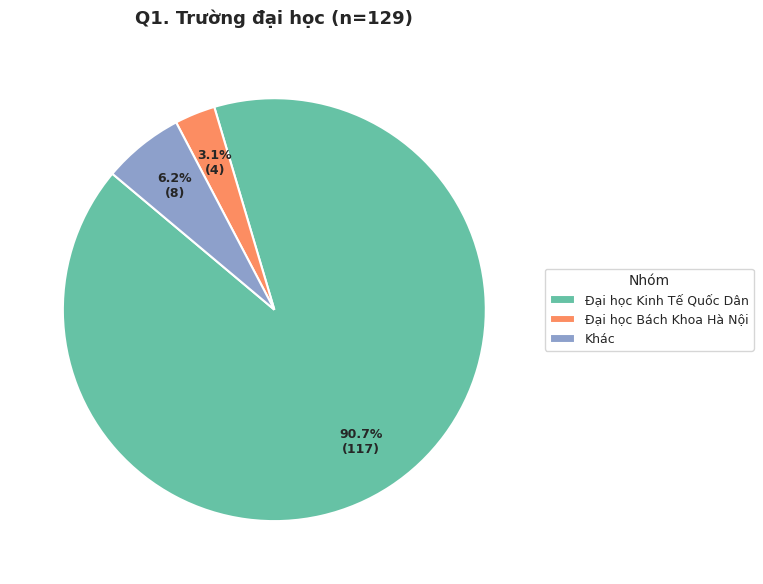

   Saved: Saved: reports/figures/1_demographics_descriptive/Q1_university_pie.png


In [3]:
# ── A1: Trường đại học ────────────────────────────────
plot_pie(df["Q1_university"],
         title=f"Q1. Trường đại học (n={N})",
         filename="Q1_university_pie.png")

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


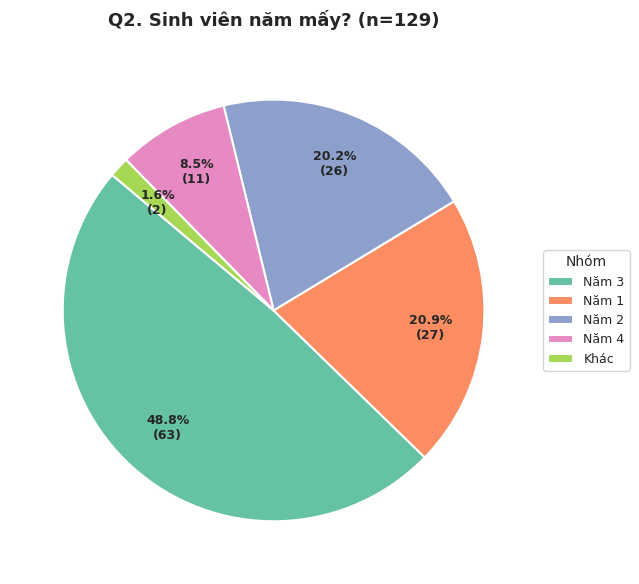

   Saved: Saved: reports/figures/1_demographics_descriptive/Q2_year_pie.png


In [4]:
# ── A2: Năm học ───────────────────────────────────────
plot_pie(df["Q2_year"],
         title=f"Q2. Sinh viên năm mấy? (n={N})",
         filename="Q2_year_pie.png")

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


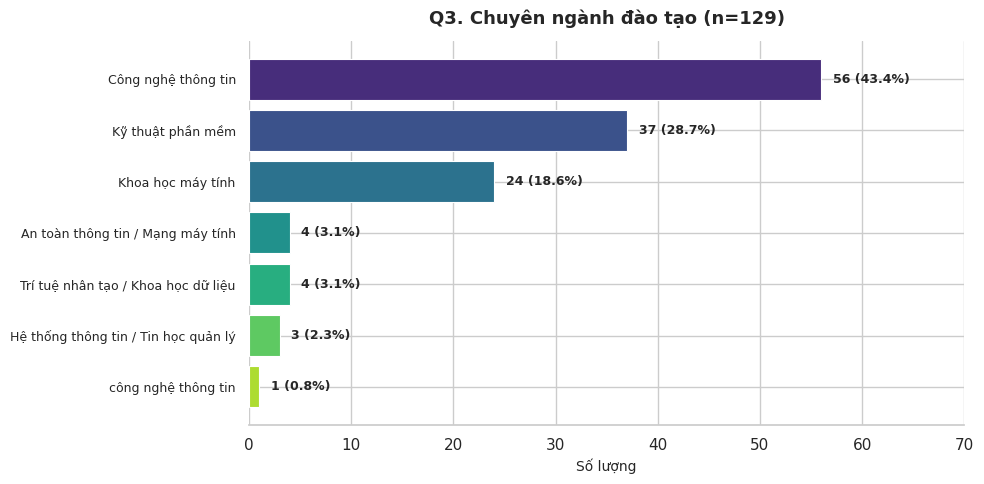

   Saved: Saved: reports/figures/1_demographics_descriptive/Q3_major_bar.png


In [5]:
# ── A3: Chuyên ngành ──────────────────────────────────
plot_bar_horizontal(df["Q3_major"],
                    title=f"Q3. Chuyên ngành đào tạo (n={N})",
                    filename="Q3_major_bar.png")

---
##  Phần B — Nhận thức & Trải nghiệm CI/CD

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


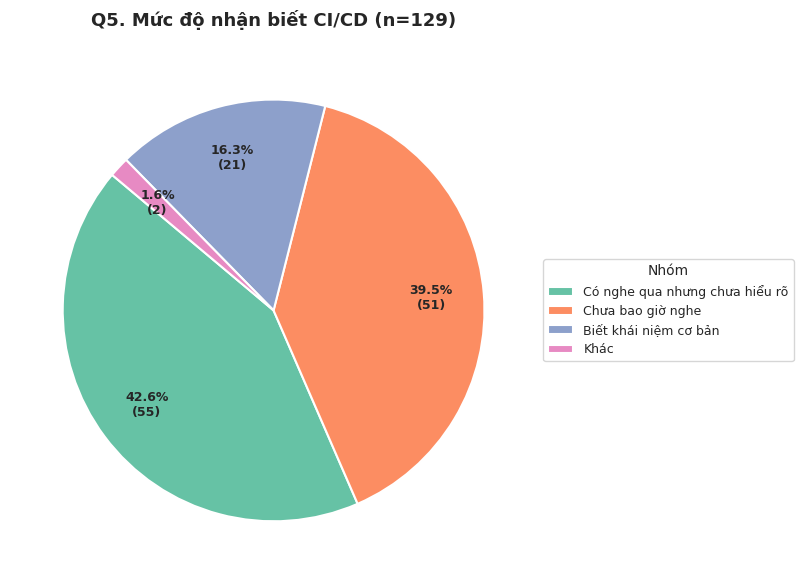

   Saved: Saved: reports/figures/1_demographics_descriptive/Q5_cicd_awareness_pie.png


In [6]:
# ── B1: Mức độ nhận biết CI/CD ────────────────────────
plot_pie(df["Q5_cicd_awareness"],
         title=f"Q5. Mức độ nhận biết CI/CD (n={N})",
         filename="Q5_cicd_awareness_pie.png")

In [7]:
# ── HÌNH 1: Phân nhóm sinh viên theo tình trạng nhận thức và sử dụng CI/CD ──
def plot_h1_student_groups(df, total, filename="h1_student_groups.png"):
    # Phân nhóm sinh viên dựa trên Q5 và Q7
    def categorize_student(row):
        q5 = str(row.get('Q5_cicd_awareness', ''))
        q7 = str(row.get('Q7_tools_used', ''))
        
        has_used_tools = False
        if q7 and q7 != 'nan' and q7 != 'Chưa từng sử dụng' and q7 != 'Không trả lời' and 'Chưa từng sử dụng' not in q7:
            has_used_tools = True
            
        if has_used_tools:
            return 'Đã dùng CI/CD'
        elif 'Chưa bao giờ nghe' in q5:
            return 'Chưa từng nghe đến CI/CD'
        else:
            return 'Biết nhưng chưa dùng'

    df_temp = df.copy()
    df_temp['Group'] = df_temp.apply(categorize_student, axis=1)
    
    # Counts and percentages
    counts = df_temp['Group'].value_counts()
    group_order = ['Đã dùng CI/CD', 'Biết nhưng chưa dùng', 'Chưa từng nghe đến CI/CD']
    counts = counts.reindex(group_order)
    
    # Colors: Emerald green, Amber, Slate gray
    colors = ['#10b981', '#f59e0b', '#6b7280']
    
    fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
    
    # Create donut chart
    wedges, texts, autotexts = ax.pie(
        counts.values,
        labels=None,
        autopct=lambda p: f"{p:.1f}%\n({int(round(p * total / 100))})",
        colors=colors,
        startangle=140,
        pctdistance=0.75,
        wedgeprops={"edgecolor": "white", "linewidth": 2, "width": 0.4},
    )
    
    # Style percentages inside wedges
    for t in autotexts:
        t.set_fontsize(10)
        t.set_fontweight("bold")
        t.set_color("white")
        
    # Circle in center to make it a donut
    centre_circle = plt.Circle((0,0), 0.55, fc='white', linewidth=0)
    fig.gca().add_artist(centre_circle)
    
    # Text in center
    ax.text(
        0, 0, f"Tổng số\n{total} SV\n(100%)",
        ha='center', va='center',
        fontsize=12, fontweight='bold', color='#374151'
    )
    
    # Legend
    legend_labels = [
        f"{name}\n(n = {counts[name]}, {counts[name]/total*100:.1f}%)"
        for name in counts.index
    ]
    
    ax.legend(
        wedges, legend_labels,
        title="Phân nhóm sinh viên",
        loc="center left",
        bbox_to_anchor=(1.05, 0.5),
        fontsize=9.5,
        title_fontsize=10.5,
        frameon=True,
        shadow=False,
        edgecolor='#e5e7eb',
        facecolor='white'
    )
    
    ax.set_title(
        "HÌNH 1 — Phân bố ba nhóm sinh viên theo tình trạng nhận thức và sử dụng CI/CD",
        fontsize=12, fontweight="bold", pad=20, color='#1f2937'
    )
    
    plt.tight_layout()
    plt.savefig(f"reports/figures/1_demographics_descriptive/{filename}", bbox_inches="tight", dpi=150)
    plt.close()  # Close the plot to avoid showing it double in notebooks
    print(f"   Saved: reports/figures/1_demographics_descriptive/{filename}")

plot_h1_student_groups(df, N)

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


   Saved: reports/figures/1_demographics_descriptive/h1_student_groups.png


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


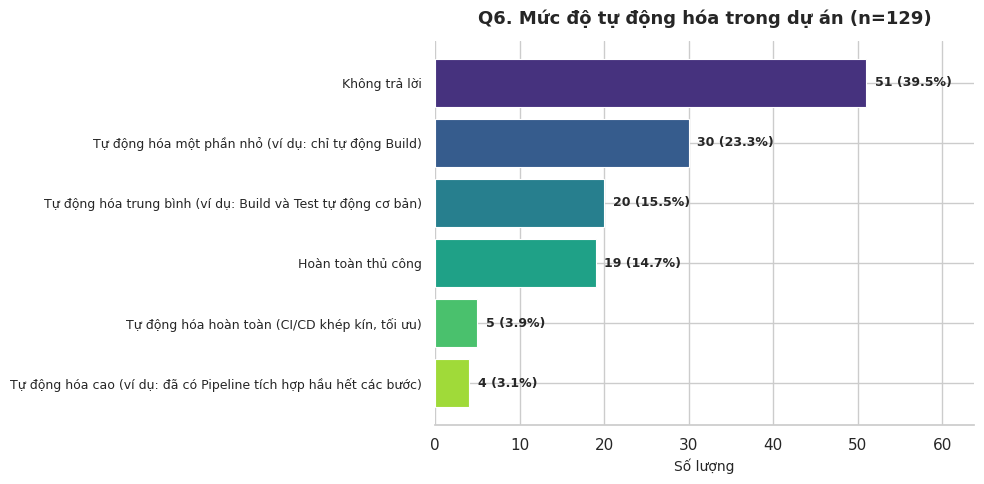

   Saved: Saved: reports/figures/1_demographics_descriptive/Q6_automation_level_bar.png


In [8]:
# ── B2: Mức độ tự động hóa ────────────────────────────
plot_bar_horizontal(df["Q6_automation_level"],
                    title=f"Q6. Mức độ tự động hóa trong dự án (n={N})",
                    filename="Q6_automation_level_bar.png")

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


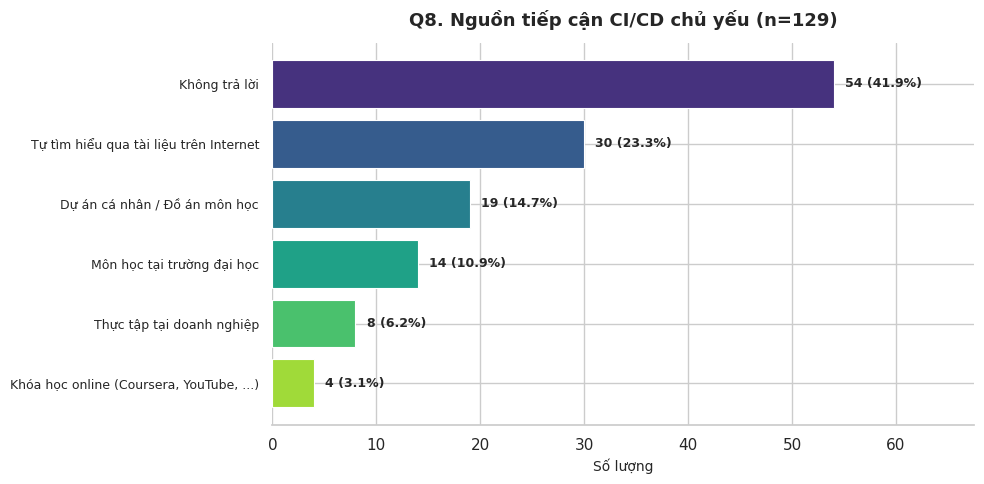

   Saved: Saved: reports/figures/1_demographics_descriptive/Q8_learning_source_bar.png


In [9]:
# ── B3: Nguồn tiếp cận CI/CD ───────────────────────────
plot_bar_horizontal(df["Q8_learning_source"],
                    title=f"Q8. Nguồn tiếp cận CI/CD chủ yếu (n={N})",
                    filename="Q8_learning_source_bar.png")

---
##  Phần C — DORA Metrics (Tần suất & Thời gian)

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


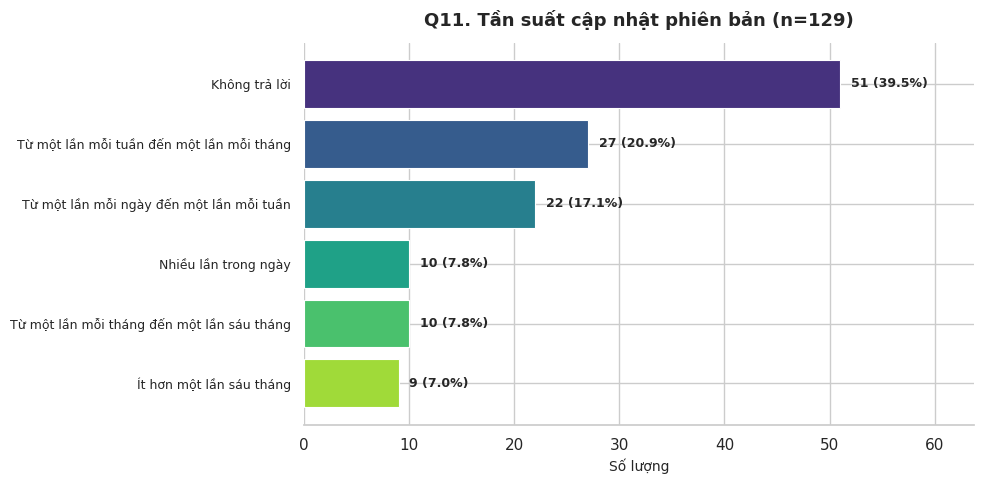

   Saved: Saved: reports/figures/1_demographics_descriptive/Q11_deploy_frequency_bar.png


In [10]:
# ── C1: Tần suất cập nhật code (Deploy Frequency) ────
plot_bar_horizontal(df["Q11_deploy_frequency"],
                    title=f"Q11. Tần suất cập nhật phiên bản (n={N})",
                    filename="Q11_deploy_frequency_bar.png")

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


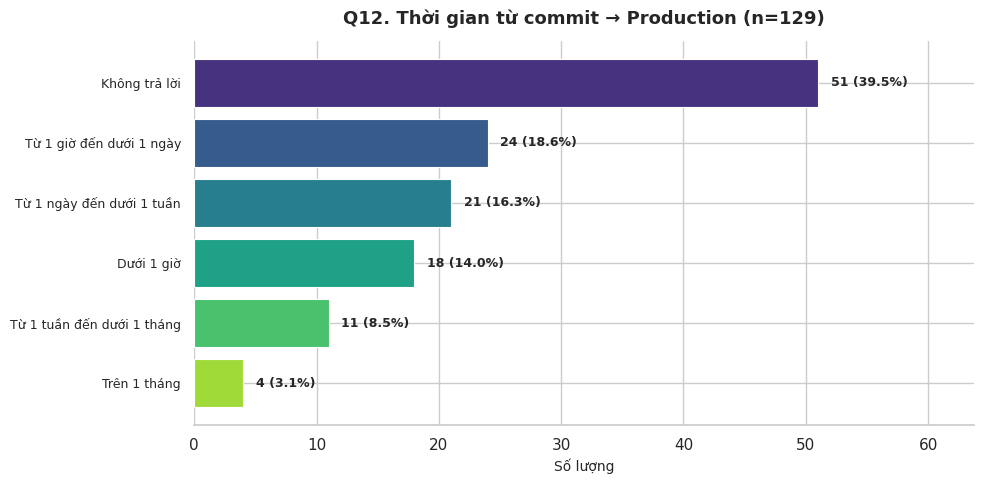

   Saved: Saved: reports/figures/1_demographics_descriptive/Q12_lead_time_bar.png


In [11]:
# ── C2: Lead time ────────────────────────────────────
plot_bar_horizontal(df["Q12_lead_time"],
                    title=f"Q12. Thời gian từ commit → Production (n={N})",
                    filename="Q12_lead_time_bar.png")

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


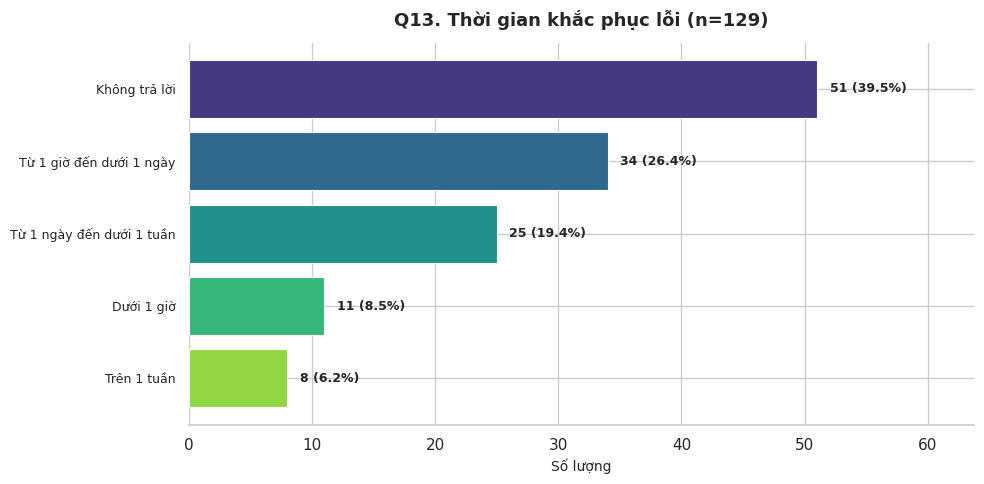

   Saved: Saved: reports/figures/1_demographics_descriptive/Q13_recovery_time_bar.png


In [12]:
# ── C3: Recovery time ────────────────────────────────
plot_bar_horizontal(df["Q13_recovery_time"],
                    title=f"Q13. Thời gian khắc phục lỗi (n={N})",
                    filename="Q13_recovery_time_bar.png")

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


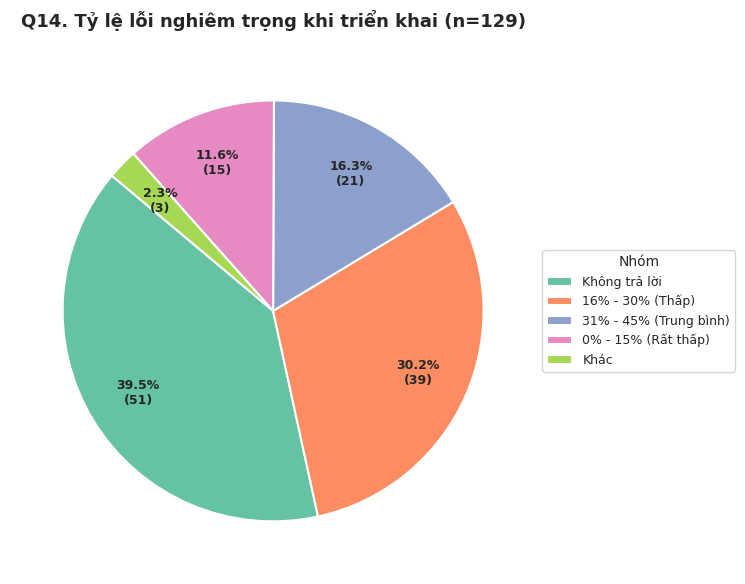

   Saved: Saved: reports/figures/1_demographics_descriptive/Q14_failure_rate_pie.png


In [13]:
# ── C4: Failure rate ─────────────────────────────────
plot_pie(df["Q14_failure_rate"],
         title=f"Q14. Tỷ lệ lỗi nghiêm trọng khi triển khai (n={N})",
         filename="Q14_failure_rate_pie.png")

---
##  Phần D — Likert Scale (Q15-Q32): Nhận thức & Thái độ

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


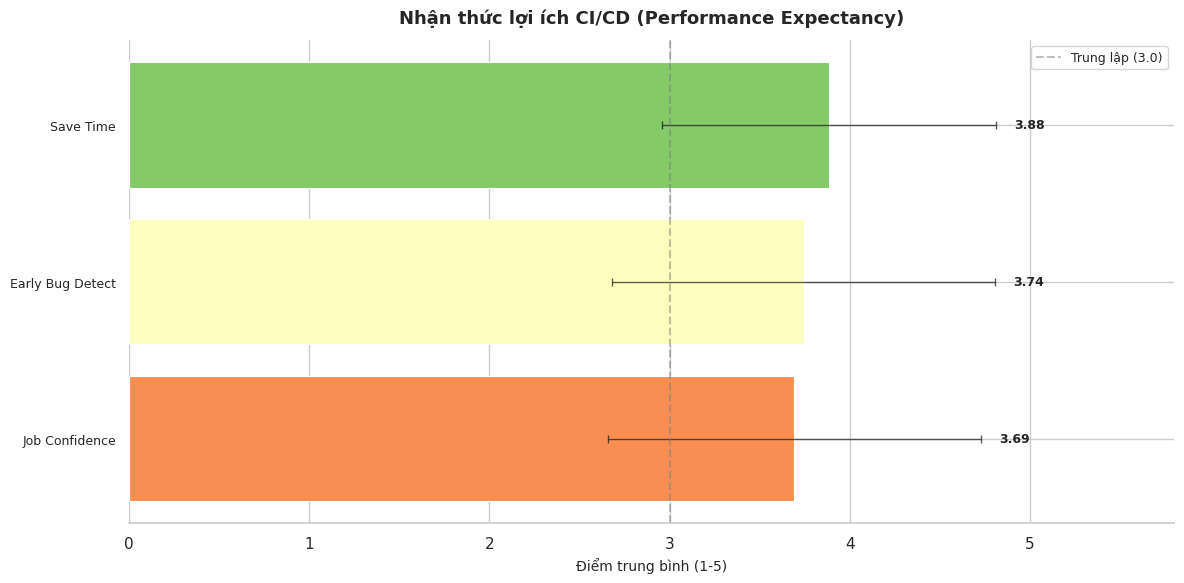

   Saved: Saved: reports/figures/1_demographics_descriptive/likert_performance_expectancy.png


In [14]:
# ── D1: Nhóm "Nhận thức lợi ích" (Performance Expectancy) ──
pe_cols = ["Q15_save_time", "Q16_early_bug_detect", "Q17_job_confidence"]
plot_likert_grouped(df[pe_cols],
                    title="Nhận thức lợi ích CI/CD (Performance Expectancy)",
                    filename="likert_performance_expectancy.png")

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


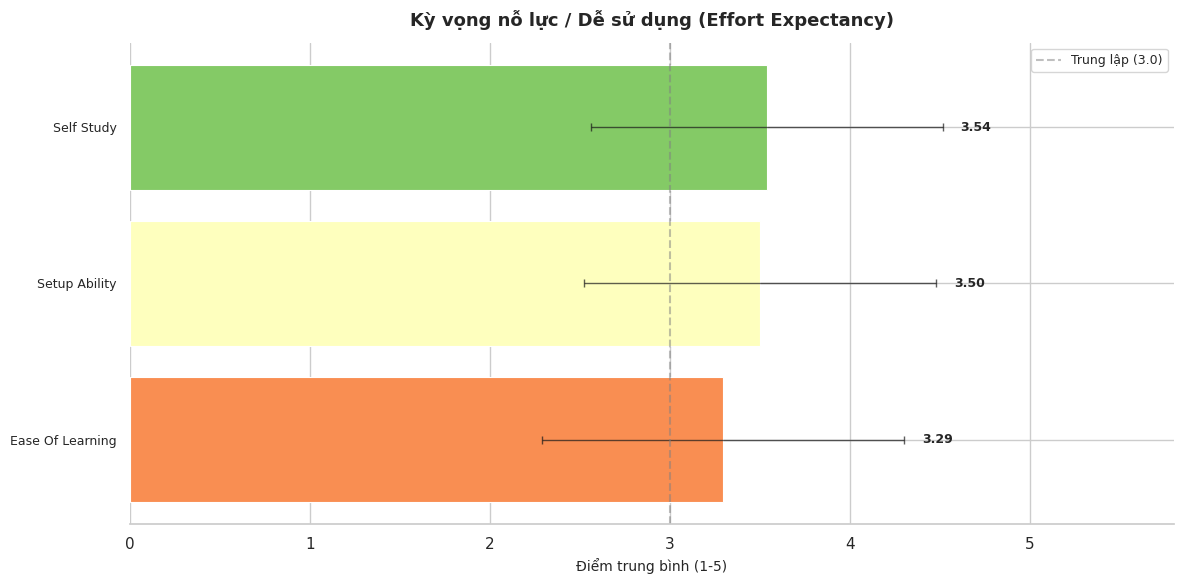

   Saved: Saved: reports/figures/1_demographics_descriptive/likert_effort_expectancy.png


In [15]:
# ── D2: Nhóm "Dễ sử dụng" (Effort Expectancy) ─────────
ee_cols = ["Q18_ease_of_learning", "Q19_self_study", "Q20_setup_ability"]
plot_likert_grouped(df[ee_cols],
                    title="Kỳ vọng nỗ lực / Dễ sử dụng (Effort Expectancy)",
                    filename="likert_effort_expectancy.png")

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


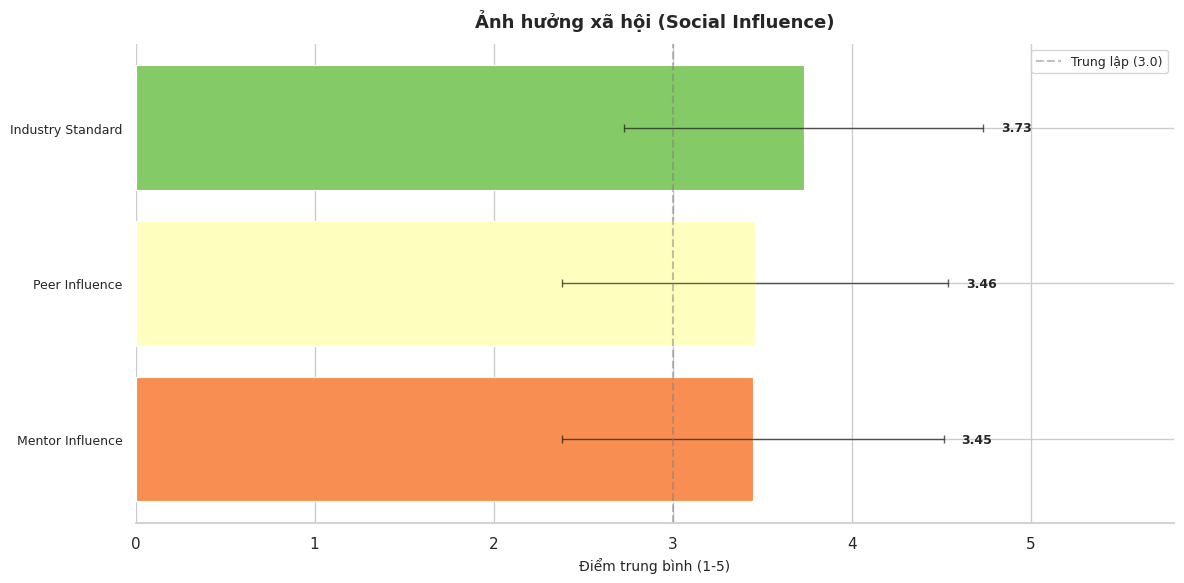

   Saved: Saved: reports/figures/1_demographics_descriptive/likert_social_influence.png


In [16]:
# ── D3: Nhóm "Ảnh hưởng xã hội" (Social Influence) ────
si_cols = ["Q21_peer_influence", "Q22_mentor_influence", "Q23_industry_standard"]
plot_likert_grouped(df[si_cols],
                    title="Ảnh hưởng xã hội (Social Influence)",
                    filename="likert_social_influence.png")

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


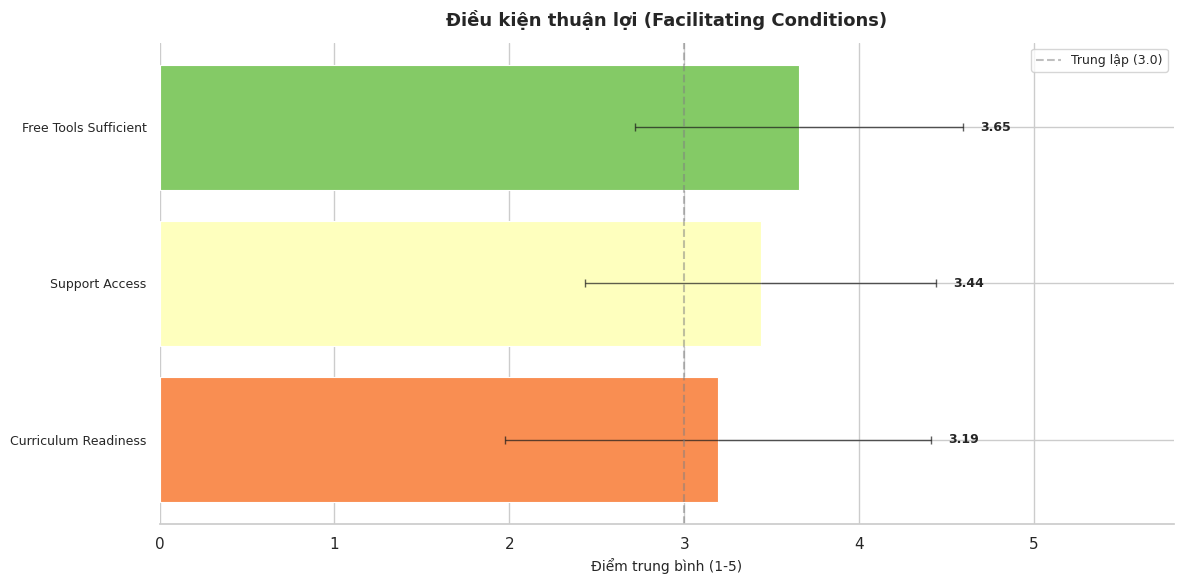

   Saved: Saved: reports/figures/1_demographics_descriptive/likert_facilitating_conditions.png


In [17]:
# ── D4: Nhóm "Điều kiện thuận lợi" (Facilitating Conditions) ──
fc_cols = ["Q24_curriculum_readiness", "Q25_free_tools_sufficient", "Q26_support_access"]
plot_likert_grouped(df[fc_cols],
                    title="Điều kiện thuận lợi (Facilitating Conditions)",
                    filename="likert_facilitating_conditions.png")

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


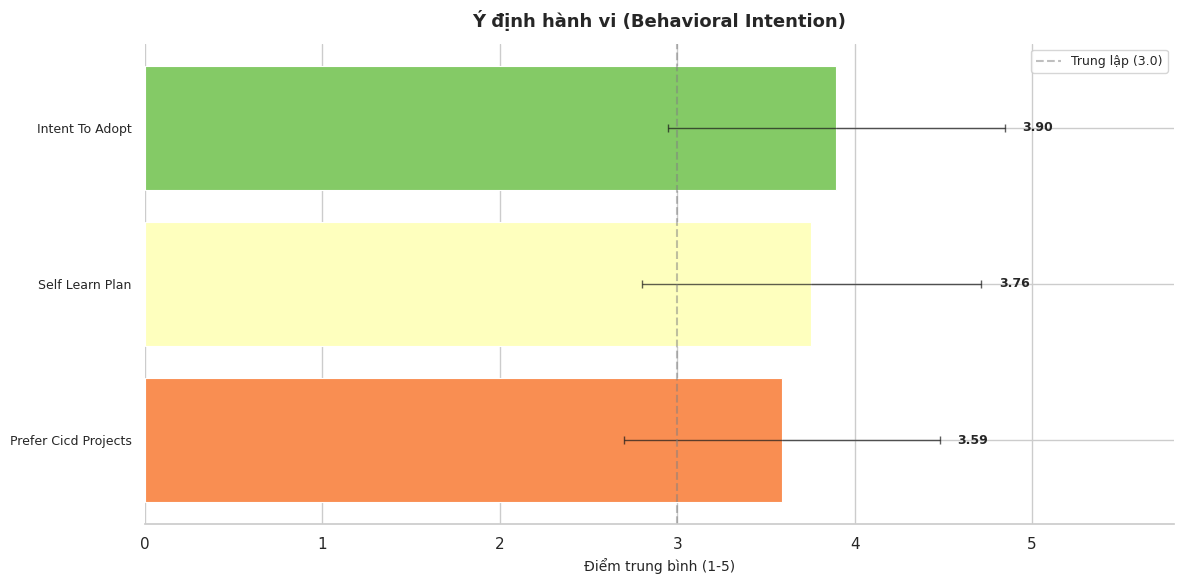

   Saved: Saved: reports/figures/1_demographics_descriptive/likert_behavioral_intention.png


In [18]:
# ── D5: Nhóm "Ý định hành vi" (Behavioral Intention) ──
bi_cols = ["Q27_intent_to_adopt", "Q28_self_learn_plan", "Q29_prefer_cicd_projects"]
plot_likert_grouped(df[bi_cols],
                    title="Ý định hành vi (Behavioral Intention)",
                    filename="likert_behavioral_intention.png")

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


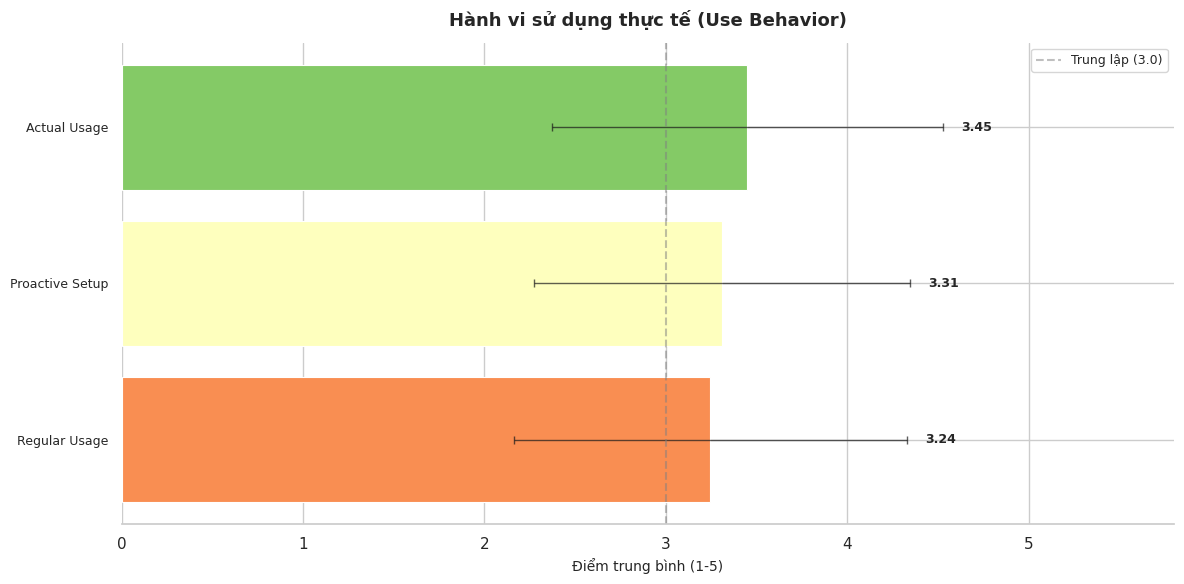

   Saved: Saved: reports/figures/1_demographics_descriptive/likert_use_behavior.png


In [19]:
# ── D6: Nhóm "Hành vi thực tế" (Use Behavior) ────────
ub_cols = ["Q30_actual_usage", "Q31_regular_usage", "Q32_proactive_setup"]
plot_likert_grouped(df[ub_cols],
                    title="Hành vi sử dụng thực tế (Use Behavior)",
                    filename="likert_use_behavior.png")

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


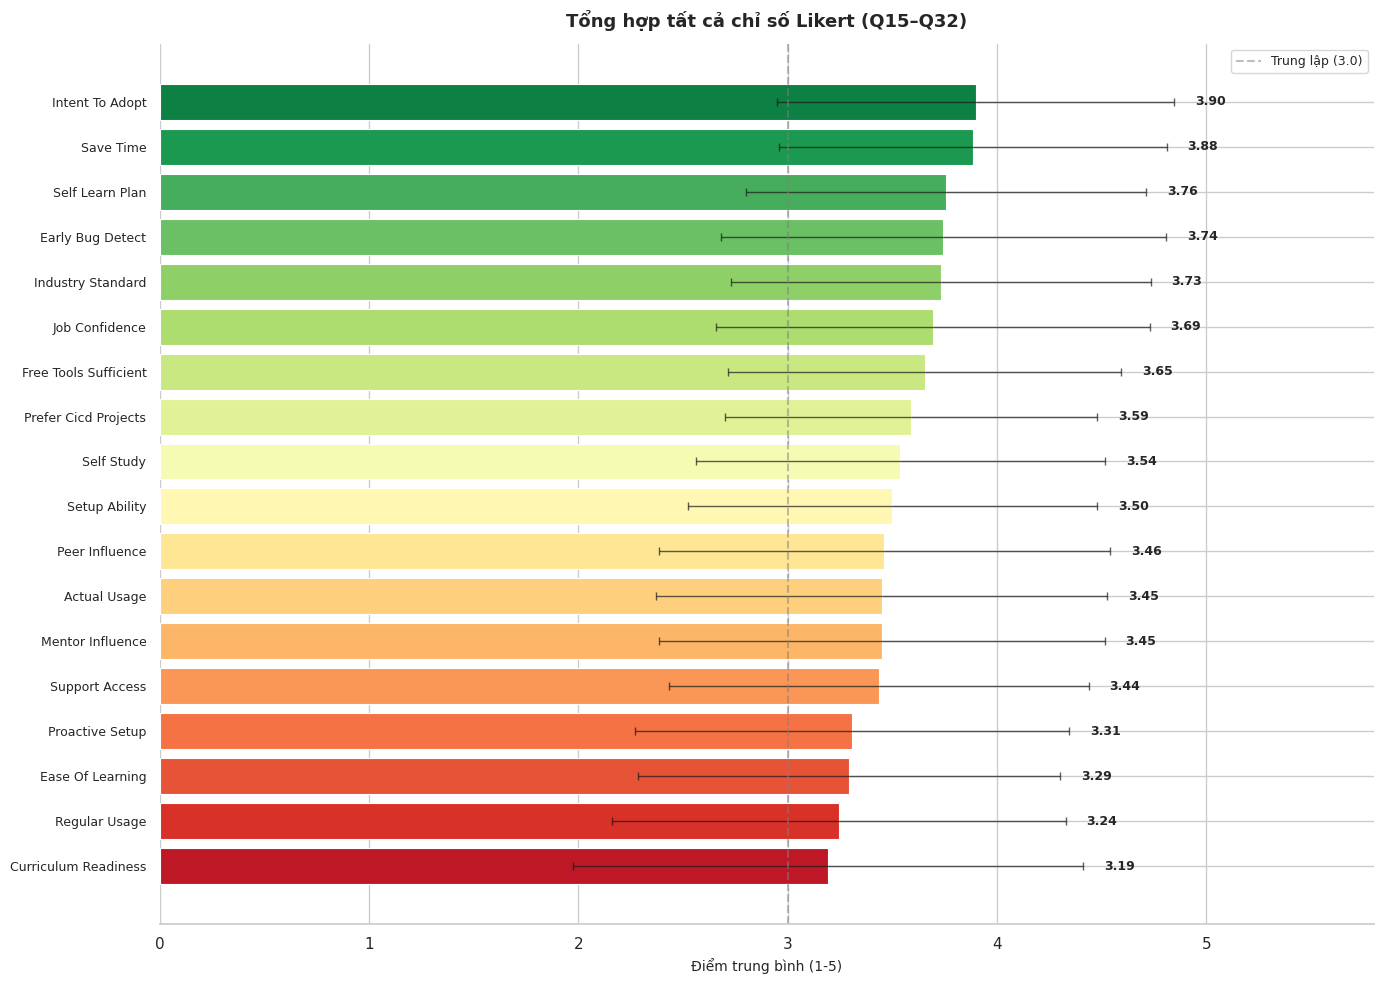

   Saved: Saved: reports/figures/1_demographics_descriptive/likert_all_overview.png


In [20]:
# ── D7: TỔNG HỢP tất cả Likert Q15-Q32 ──────────────
all_likert = [c for c in df.columns if c.startswith("Q") and df[c].dtype in ["int64", "float64"]]
plot_likert_grouped(df[all_likert],
                    title="Tổng hợp tất cả chỉ số Likert (Q15–Q32)",
                    filename="likert_all_overview.png",
                    figsize=(14, 10))

---
##  Phần E — Dự định tương lai (Q38)

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


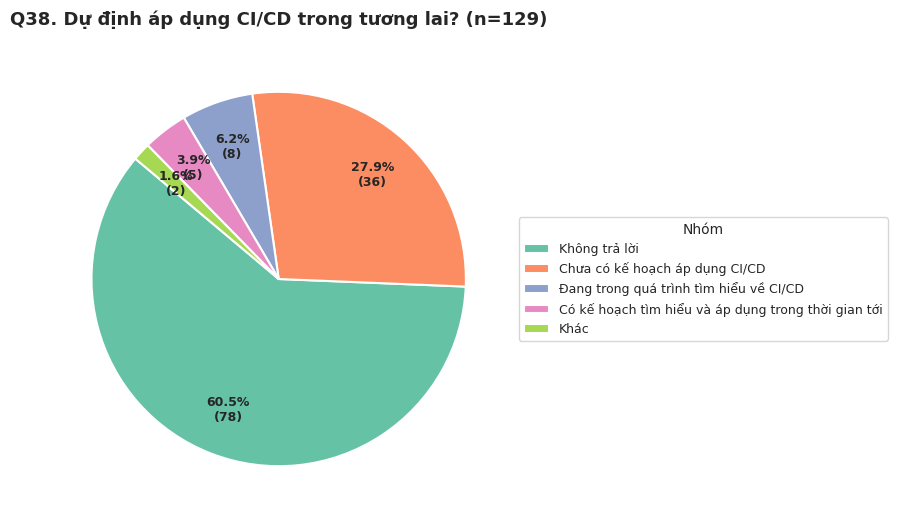

   Saved: Saved: reports/figures/1_demographics_descriptive/Q38_future_plan_pie.png


In [21]:
# ── E1: Dự định áp dụng CI/CD ────────────────────────
plot_pie(df["Q38_future_plan"],
         title=f"Q38. Dự định áp dụng CI/CD trong tương lai? (n={N})",
         filename="Q38_future_plan_pie.png")

In [22]:
# ══════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════

output_files = [f for f in os.listdir("reports/figures/1_demographics_descriptive") if f.endswith(".png")]
print(f"\n{'═'*50}")
print(f"[OK] HOÀN TẤT: 2a_preliminary_analysis")
print(f"   Tổng biểu đồ đã lưu: {len(output_files)} file")
print(f"   Thư mục: reports/figures/1_demographics_descriptive/")
for f in sorted(output_files):
    size_kb = os.path.getsize(f'reports/figures/1_demographics_descriptive/{f}') / 1024
    print(f"    {f} ({size_kb:.0f} KB)")
print(f"{'═'*50}")


══════════════════════════════════════════════════
[OK] HOÀN TẤT: 2a_preliminary_analysis
   Tổng biểu đồ đã lưu: 19 file
   Thư mục: reports/figures/1_demographics_descriptive/
    Q11_deploy_frequency_bar.png (70 KB)
    Q12_lead_time_bar.png (59 KB)
    Q13_recovery_time_bar.png (51 KB)
    Q14_failure_rate_pie.png (82 KB)
    Q1_university_pie.png (59 KB)
    Q2_year_pie.png (70 KB)
    Q38_future_plan_pie.png (85 KB)
    Q3_major_bar.png (71 KB)
    Q5_cicd_awareness_pie.png (73 KB)
    Q6_automation_level_bar.png (80 KB)
    Q8_learning_source_bar.png (68 KB)
    h1_student_groups.png (91 KB)
    likert_all_overview.png (126 KB)
    likert_behavioral_intention.png (44 KB)
    likert_effort_expectancy.png (46 KB)
    likert_facilitating_conditions.png (47 KB)
    likert_performance_expectancy.png (47 KB)
    likert_social_influence.png (45 KB)
    likert_use_behavior.png (45 KB)
══════════════════════════════════════════════════
